# Installing Dependencies


In [1]:
%pip install tensorflow numpy pandas scikit-learn matplotlib pillow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Data Load


## ⚙️ Path Configuration

**Change `BASE_DIR` below to match where you extracted `img.zip`.**

Expected structure after extraction:
```
BASE_DIR/
  img/
    001bd5563b4511f0b16c00155d672fff.png
    d13cde743b4411f0b16c00155d672fff.jpg
    ...
  train-label.csv
  test-label.csv
  submission.csv
```

In [2]:
import os
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
#  CHANGE THIS to your local path where the dataset lives
# ─────────────────────────────────────────────────────────────
BASE_DIR = '.'          # e.g. '/Users/yourname/Downloads/knu_ml'
IMG_DIR  = os.path.join(BASE_DIR, 'img')  # folder containing all images

TRAIN_LABEL = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'), index_col='id')
TEST_LABEL  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'),  index_col='id')

# TRAIN_DATA and TEST_DATA will be loaded as image arrays below
TRAIN_DATA = None   # placeholder – set after preprocessing
TEST_DATA  = None   # placeholder – set after preprocessing

print('Train samples:', len(TRAIN_LABEL))
print('Test  samples:', len(TEST_LABEL))
print('Label distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())

Train samples: 1385
Test  samples: 1386
Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64


## 1. Imports & Reproducibility

In [3]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))
print('Metal (Apple Silicon) devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []
Metal (Apple Silicon) devices: []


## 2. Hyperparameters

In [4]:
# ── Image settings ───────────────────────────────────────────
IMG_HEIGHT   = 128         # resize all images to this height
IMG_WIDTH    = 128         # resize all images to this width
IMG_CHANNELS = 3           # RGB

# ── Training settings ────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 50          # 모델이 깊어졌으므로 에폭을 50으로 약간 늘립니다.
LR_INIT      = 1e-3        # Cosine Decay가 적용됩니다.
DROPOUT_RATE = 0.4         # Classifier Head용 Dropout
L2_LAMBDA    = 1e-4        # 과적합 방지용 L2 규제 강도
VAL_SPLIT    = 0.15

## 3. Data Loading & Preprocessing

In [5]:
def load_image(filepath: str) -> np.ndarray:
    """Load one image, convert to RGB, resize to (IMG_HEIGHT, IMG_WIDTH)."""
    img = Image.open(filepath).convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0   # [0, 1] normalisation


def load_dataset(label_df: pd.DataFrame, img_dir: str, has_labels: bool = True):
    """Load all images listed in label_df.
    Returns (X, y) where X is (N, H, W, C) float32, y is (N,) int32 or None.
    """
    images, labels = [], []
    missing = 0
    for row_id, row in label_df.iterrows():
        path = os.path.join(img_dir, row['file'])
        if not os.path.exists(path):
            missing += 1
            continue
        images.append(load_image(path))
        if has_labels:
            labels.append(int(row['label']))
    if missing > 0:
        print(f'  ⚠️  {missing} images not found – skipped')
    X = np.stack(images).astype(np.float32)           # (N, H, W, C)
    y = np.array(labels, dtype=np.int32) if has_labels else None
    return X, y


print('Loading train images …')
X_all, y_all = load_dataset(TRAIN_LABEL, IMG_DIR, has_labels=True)
print(f'  Train shape: {X_all.shape}, labels: {y_all.shape}')

print('Loading test images …')
X_test, _ = load_dataset(TEST_LABEL, IMG_DIR, has_labels=False)
print(f'  Test  shape: {X_test.shape}')

# Assign to template variables
TRAIN_DATA = X_all
TEST_DATA  = X_test

Loading train images …
  Train shape: (1385, 128, 128, 3), labels: (1385,)
Loading test images …
  Test  shape: (1386, 128, 128, 3)


## 4. Exploratory Visualisation

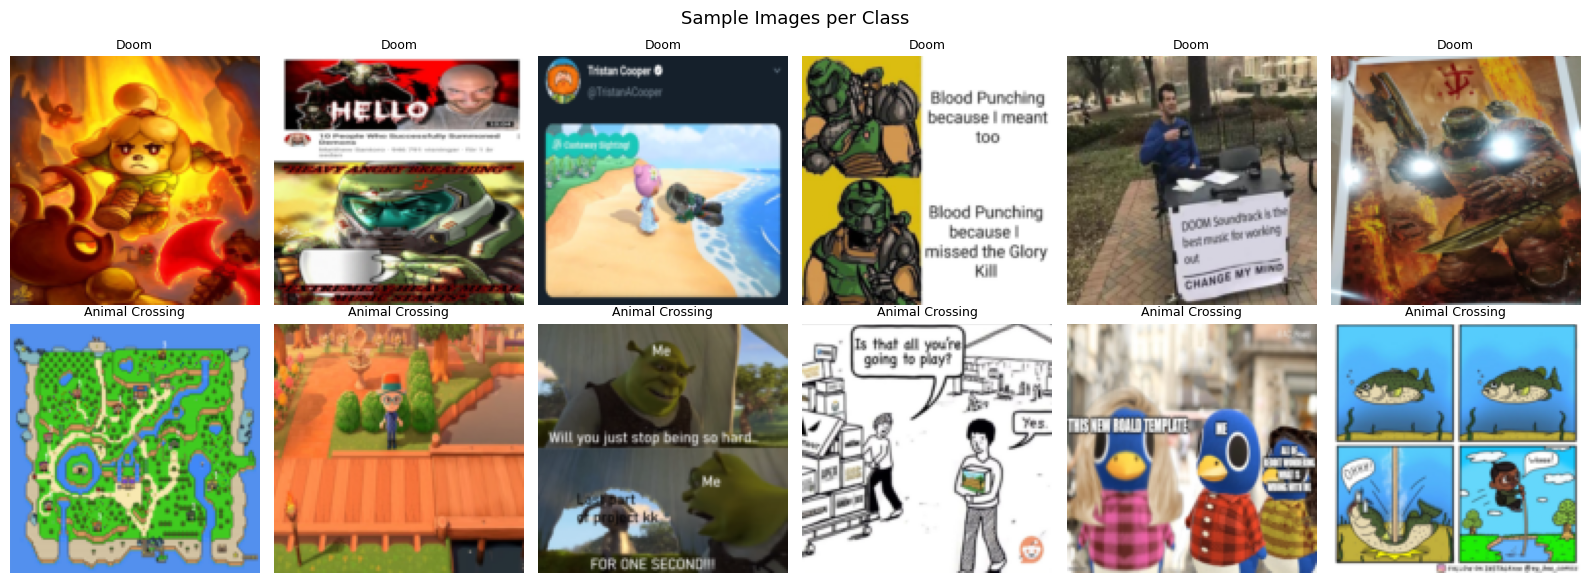

Label distribution →  Doom (0): 707   Animal Crossing (1): 678


In [6]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for cls, cls_name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    idx = np.where(y_all == cls)[0]
    row = 0 if cls == 0 else 1
    for col in range(6):
        axes[row, col].imshow(X_all[idx[col]])
        axes[row, col].set_title(cls_name, fontsize=9)
        axes[row, col].axis('off')
plt.suptitle('Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.show()

print('Label distribution →  Doom (0):', (y_all == 0).sum(),
      '  Animal Crossing (1):', (y_all == 1).sum())

## 5. Train / Validation Split

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_all          # keep class balance in both splits
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}')

Train: (1177, 128, 128, 3)  Val: (208, 128, 128, 3)


## 6. Data Augmentation Pipeline

We apply random flips, rotations, zoom, and brightness shifts **only during training** to reduce overfitting — a common challenge with deep networks (lecture: *Prevent Overfitting*, Dropout & regularisation).

In [8]:
def make_augment_fn():
    """Return a tf.function that augments a single (H, W, C) image tensor."""
    @tf.function
    def augment(image, label):
        # 1. 좌우 반전만 허용 (상하 반전은 글자를 깨뜨리므로 제거)
        image = tf.image.random_flip_left_right(image)

        # 2. 미세한 밝기 및 대비 조절
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

        # 3. 미세한 랜덤 크롭 (과적합 방지)
        pad = int(IMG_HEIGHT * 0.05) # 5%만 패딩
        image = tf.image.pad_to_bounding_box(image, pad, pad, IMG_HEIGHT + 2*pad, IMG_WIDTH + 2*pad)
        image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])

        image = tf.clip_by_value(image, 0.0, 1.0)
        return image, label
    return augment

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .map(make_augment_fn(), num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset
            .from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset
            .from_tensor_slices(X_test)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print('Advanced Datasets ready.')

Advanced Datasets ready.


## 7. Deep Neural Network Architecture

We build a **CNN-based Deep Neural Network trained from scratch** (no pre-trained weights).

Design choices based on lecture material:
- **ReLU** activation (computationally cheap, avoids vanishing gradients — lecture *Activation Function Matters*)
- **He initialisation** for ReLU layers (*Weight Matters: Weight Initialization*)
- **Batch Normalisation** after each conv block (*Input Matters: Batch Normalization*)
- **Dropout** on fully-connected layers (*Dropout Layer*)
- **L2 regularisation** on dense layers
- **Adam** optimiser (*Faster Gradient Descent*)
- **Cosine Decay** learning rate schedule (*Learning Rate Scheduling*)

In [9]:
def conv_block(x, filters, kernel_size=3, strides=1):
    """Conv → BN → ReLU 형식의 고도화된 빌딩 블록"""
    x = layers.Conv2D(
        filters, kernel_size,
        strides=strides,
        padding='same',
        use_bias=False,
        kernel_initializer='he_normal', # ReLU에 최적화된 초기화
        kernel_regularizer=regularizers.l2(L2_LAMBDA)
    )(x)
    x = layers.BatchNormalization()(x) # 그래디언트 안정화 및 학습 가속화
    x = layers.Activation('relu')(x)
    return x

def build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=2):
    inputs = keras.Input(shape=input_shape)

    # ── Block 1: 32 Filters (Low-level features) ──
    x = conv_block(inputs, 32)
    x = conv_block(x, 32)
    x = layers.MaxPooling2D(2)(x) # 128x128 -> 64x64
    x = layers.Dropout(0.2)(x)

    # ── Block 2: 64 Filters (Mid-level features) ──
    x = conv_block(x, 64)
    x = conv_block(x, 64)
    x = layers.MaxPooling2D(2)(x) # 64x64 -> 32x32
    x = layers.Dropout(0.2)(x)

    # ── Block 3: 128 Filters (High-level features) ──
    x = conv_block(x, 128)
    x = conv_block(x, 128)
    x = layers.MaxPooling2D(2)(x) # 32x32 -> 16x16
    x = layers.Dropout(0.3)(x)

    # ── Block 4: 256 Filters (Complex semantic features) ──
    x = conv_block(x, 256)
    x = conv_block(x, 256)
    x = layers.MaxPooling2D(2)(x) # 16x16 -> 8x8
    x = layers.Dropout(0.3)(x)

    # ── Global Average Pooling ──
    # Flatten 대신 GAP를 사용하여 공간 정보를 압축하고 Dense 레이어의 파라미터 폭발을 막음 (오버핏 방지 핵심)
    x = layers.GlobalAveragePooling2D()(x)

    # ── Classifier Head ──
    x = layers.Dense(
        512,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(L2_LAMBDA)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # 최종 출력층 (SparseCategoricalCrossentropy를 사용하므로 크기는 num_classes=2)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='Advanced_Meme_Classifier')

model = build_model()
model.summary()

Model: "Advanced_Meme_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,309,794 (5.00 MB)

 Trainable params: 1,306,850 (4.99 MB)

 Non-trainable params: 2,944 (11.50 KB)

## 8. Compile with Cosine Decay LR + Adam

In [10]:
# 1. Cosine Decay Learning Rate 설정
steps_per_epoch = len(X_train) // BATCH_SIZE
total_steps     = EPOCHS * steps_per_epoch
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_INIT,
    decay_steps=total_steps,
    alpha=1e-5
)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 2. 고도화된 콜백 리스트 (런타임 정체 시 LR 자동 감소 스케줄러 추가)
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    )
]

print('Model compiled with advanced strategy.')

Model compiled with advanced strategy.


## 9. Callbacks

In [11]:
callbacks = [
    # Save the best model by val_accuracy
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Stop early if val_accuracy stops improving for 12 epochs
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    )
]

## 10. Training

In [12]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6392 - loss: 1.1681
Epoch 1: val_accuracy improved from None to 0.55288, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6389 - loss: 1.1098 - val_accuracy: 0.5529 - val_loss: 1.2071
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.6757 - loss: 1.0054
Epoch 2: val_accuracy improved from 0.55288 to 0.56250, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6678 - loss: 0.9777 - val_accuracy: 0.5625 - val_loss: 1.4073
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6745 - loss: 0.9848
Epoch 3: val_accuracy improved from 0.56250 to 0.64904, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6686 - loss: 0.9986 - val_accuracy: 0.6490 - val_loss: 0.9295
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6904 - loss: 0.9636
Epoch 4: val_accuracy did not improve from 0.64904
37/37

## 11. Training Curves

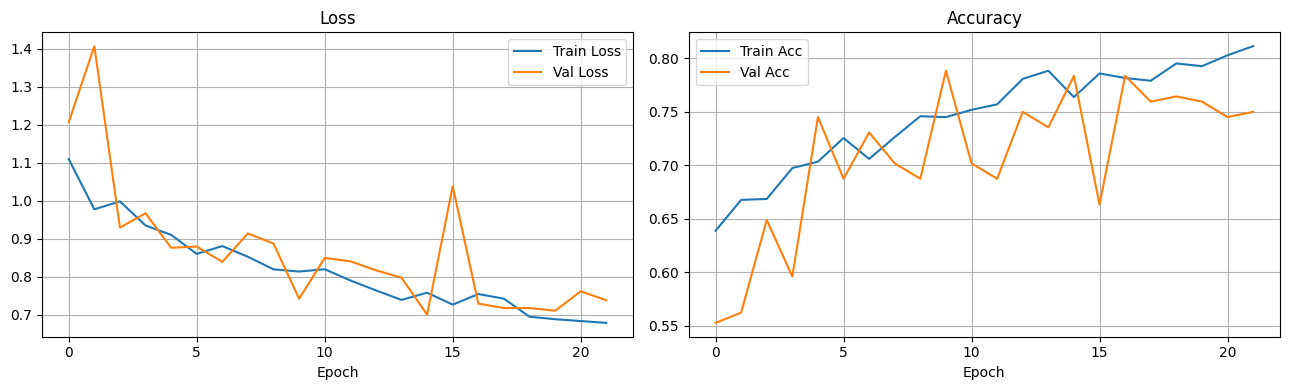

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 12. Validation Evaluation (Balanced Accuracy)

In [14]:
# Predict on validation set
val_probs = model.predict(val_ds, verbose=0)  # (N, 2)
val_preds = np.argmax(val_probs, axis=1)

bal_acc = balanced_accuracy_score(y_val, val_preds)
print(f'Validation Balanced Accuracy: {bal_acc:.4f}')

# Per-class accuracy
for cls, name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    mask   = y_val == cls
    cls_acc = (val_preds[mask] == y_val[mask]).mean()
    print(f'  Class {cls} ({name:15s}): {cls_acc:.4f}')

Validation Balanced Accuracy: 0.7878
  Class 0 (Doom           ): 0.8208
  Class 1 (Animal Crossing): 0.7549


## 13. Test Set Prediction

In [15]:
test_probs = model.predict(test_ds, verbose=0)  # (N_test, 2)
test_preds = np.argmax(test_probs, axis=1)

print('Test predictions shape:', test_preds.shape)
print('Predicted label distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Label {u}: {c}')

Test predictions shape: (1386,)
Predicted label distribution:
  Label 0: 775
  Label 1: 611


# Generating Final Submissions


In [16]:
# Build submission DataFrame aligned to TEST_LABEL index
# (test images were loaded in TEST_LABEL order)
test_ids = TEST_LABEL.index.tolist()

submission = pd.DataFrame({
    'id':    test_ids,
    'label': test_preds
})
submission = submission.set_index('id')

submission.to_csv('submission8.csv')
print('submission.csv saved!')
print(submission.head(10))

submission.csv saved!
      label
id         
2078      0
2079      1
2080      0
2081      0
2082      0
2083      1
2084      0
2085      0
2086      0
2087      0


## ✅ Verify submission format

In [17]:
sub_check = pd.read_csv('submission.csv', index_col='id')
print('Submission shape:', sub_check.shape)
print('Unique labels:', sorted(sub_check['label'].unique()))
assert set(sub_check['label'].unique()).issubset({0, 1}), \
    'ERROR: labels must be 0 or 1!'
assert len(sub_check) == len(TEST_LABEL), \
    f'ERROR: expected {len(TEST_LABEL)} rows, got {len(sub_check)}'
print('✅ Submission looks correct – ready to upload to Kaggle!')

Submission shape: (1386, 1)
Unique labels: [np.int64(-1)]


AssertionError: ERROR: labels must be 0 or 1!